In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/bike_sales_india.csv')

understading and cleaning the data


In [6]:
df.shape

(10000, 15)

In [7]:
df.head()

,State,Avg Daily Distance (km),Brand,Model,Price (INR),Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,Karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,Tier 3
1,Rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,Tier 3
2,Madhya Pradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,Tier 3
3,Karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,Tier 1
4,Madhya Pradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,Tier 3


In [8]:
df.isna().sum()

,0
State,0
Avg Daily Distance (km),0
Brand,0
Model,0
Price (INR),0
Year of Manufacture,0
Engine Capacity (cc),0
Fuel Type,0
Mileage (km/l),0
Owner Type,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    10000 non-null  object 
 1   Avg Daily Distance (km)  10000 non-null  float64
 2   Brand                    10000 non-null  object 
 3   Model                    10000 non-null  object 
 4   Price (INR)              10000 non-null  int64  
 5   Year of Manufacture      10000 non-null  int64  
 6   Engine Capacity (cc)     10000 non-null  int64  
 7   Fuel Type                10000 non-null  object 
 8   Mileage (km/l)           10000 non-null  float64
 9   Owner Type               10000 non-null  object 
 10  Registration Year        10000 non-null  int64  
 11  Insurance Status         10000 non-null  object 
 12  Seller Type              10000 non-null  object 
 13  Resale Price (INR)       10000 non-null  float64
 14  City Tier              

In [11]:
df.columns = df.columns.str.lower()

In [12]:
df.sample(5)

,state,avg daily distance (km),brand,model,price (inr),year of manufacture,engine capacity (cc),fuel type,mileage (km/l),owner type,registration year,insurance status,seller type,resale price (inr),city tier
9449,Uttar Pradesh,32.32,Yamaha,Fascino 125,168415,2019,592,Petrol,45.76,Second,2019,Expired,Individual,89330.39,Tier 1
5179,Rajasthan,16.18,KTM,125 Duke,170535,2022,153,Electric,63.35,First,2022,Active,Individual,114801.07,Tier 1
6937,Delhi,44.02,Bajaj,Dominar 400,149253,2018,968,Hybrid,77.45,First,2018,Active,Dealer,110364.03,Tier 3
8899,Uttar Pradesh,30.93,Honda,Activa,139485,2022,810,Hybrid,99.06,Third,2022,Active,Individual,60402.72,Tier 1
6339,Tamil Nadu,40.26,TVS,Sport,260418,2017,236,Hybrid,97.73,Second,2022,Not Available,Individual,151691.23,Tier 3


In [13]:
df['state'].unique()

array(['Karnataka', 'Rajasthan', 'Madhya Pradesh', 'Maharashtra',
       'Tamil Nadu', 'Punjab', 'Gujarat', 'Uttar Pradesh', 'Delhi',
       'West Bengal'], dtype=object)

In [14]:
df['state'] = df['state'].str.lower().str.strip().replace(' ','',regex=True)
df['state'].unique()

array(['karnataka', 'rajasthan', 'madhyapradesh', 'maharashtra',
       'tamilnadu', 'punjab', 'gujarat', 'uttarpradesh', 'delhi',
       'westbengal'], dtype=object)

In [15]:
df.rename(columns = {'avg daily distance (km)':'daily_mileage','price (inr)':'price','year of manufacture':'manu_year','mileage (km/l)':'mileage','resale price (inr)':'resale price','engine capacity (cc)':'engine_capacity'},inplace=True)
df.columns = df.columns.str.strip().str.replace(' ','_',regex=False)

<Axes: ylabel='Frequency'>

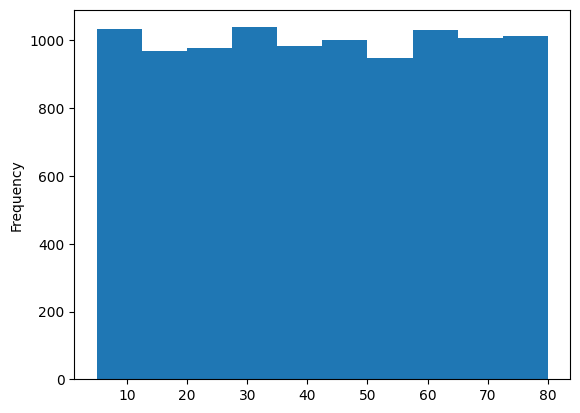

In [16]:
df['daily_mileage'].plot(kind='hist')

<Axes: xlabel='brand'>

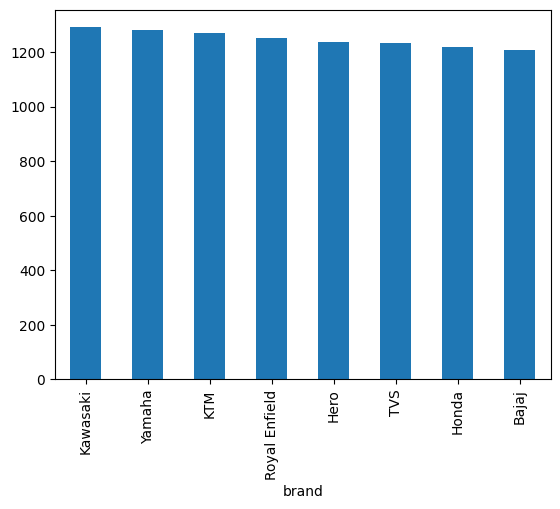

In [17]:
df['brand'].value_counts().plot(kind='bar')

In [18]:
df['model'].unique()

array(['Hunter 350', 'Dominar 400', '125 Duke', 'Ninja 300', 'FZ V3',
       'Splendor Plus', 'Meteor 350', 'Vulcan S', '390 Adventure',
       'HF Deluxe', 'Jupiter', 'Z650', 'Fascino 125', 'Xtreme 160R',
       'Versys 650', 'Glamour', 'MT-15', 'Activa', 'Ray ZR',
       'Avenger 220', 'Passion Pro', 'NTorq 125', 'R15 V4', 'Unicorn',
       'Ronin', 'Platina 110', 'Pulsar 150', 'Duke 200', 'Shine',
       'Classic 350', 'Dio', 'Sport', 'Ninja 400', 'Apache RTR 160',
       'RC 390', 'Interceptor 650', 'CBR 650R', 'CT 100', '250 Duke',
       'Himalayan'], dtype=object)

In [19]:
df['price'].describe()

,price
count,10000.000000
mean,224328.722400
std,100753.660447
min,50031.000000
25%,137900.250000
50%,223878.000000
75%,311464.250000
max,399981.000000


In [20]:
print(df['manu_year'].unique())
print(df['manu_year'].value_counts())

[2021 2020 2019 2022 2024 2015 2017 2018 2016 2023]
manu_year
2015    1060
2024    1051
2023    1029
2019    1019
2022     987
2016     987
2017     977
2020     969
2018     961
2021     960
Name: count, dtype: int64


<Axes: xlabel='fuel_type'>

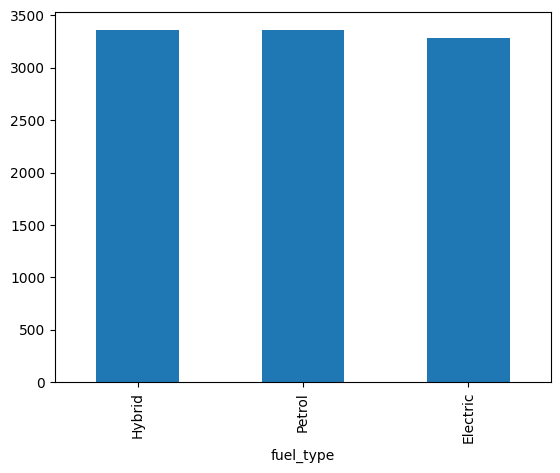

In [21]:
df['fuel_type'].value_counts().plot(kind='bar')

<Axes: ylabel='Density'>

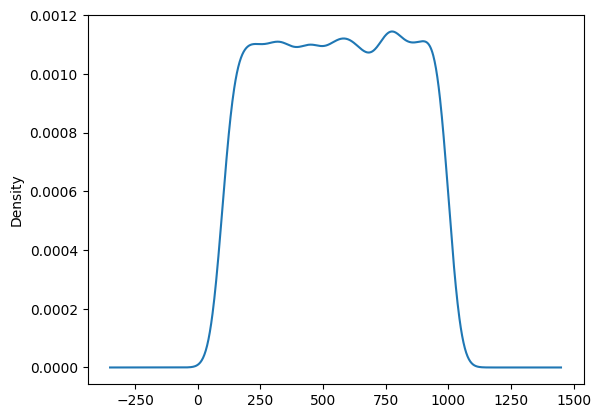

In [22]:
df['engine_capacity'].plot(kind='kde')

<Axes: ylabel='Frequency'>

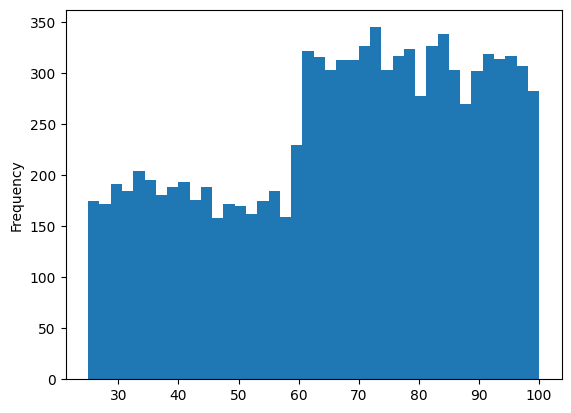

In [23]:
df['mileage'].plot(kind='hist',bins=40)

In [24]:
df['seller_type'].unique()

array(['Individual', 'Dealer'], dtype=object)

In [25]:
df['insurance_status'].unique()

array(['Active', 'Not Available', 'Expired'], dtype=object)

In [26]:
df['city_tier'] = df['city_tier'].str.split(' ').str[-1]

In [27]:
df['city_tier'].value_counts()

,count
city_tier,
3,2617
2,2487
Metro,2474
1,2422


In [28]:
df.sample(5)

,state,daily_mileage,brand,model,price,manu_year,engine_capacity,fuel_type,mileage,owner_type,registration_year,insurance_status,seller_type,resale_price,city_tier
3471,westbengal,79.95,KTM,RC 390,110363,2024,886,Hybrid,71.43,First,2024,Not Available,Individual,52065.73,Metro
3088,gujarat,28.96,Bajaj,CT 100,311371,2021,583,Electric,76.25,Second,2022,Active,Dealer,242886.23,1
1455,gujarat,48.36,Honda,Activa,290311,2015,907,Electric,87.05,Third,2016,Active,Dealer,173572.40,1
7662,rajasthan,18.41,Royal Enfield,Hunter 350,354067,2024,969,Hybrid,77.75,Third,2024,Active,Individual,227412.05,2
4300,delhi,59.90,Yamaha,MT-15,360084,2021,595,Petrol,57.86,Second,2023,Active,Dealer,227035.54,3


In [29]:
df['owner_type'].value_counts()

,count
owner_type,
First,3407
Second,3336
Third,3257


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   state              10000 non-null  object 
 1   daily_mileage      10000 non-null  float64
 2   brand              10000 non-null  object 
 3   model              10000 non-null  object 
 4   price              10000 non-null  int64  
 5   manu_year          10000 non-null  int64  
 6   engine_capacity    10000 non-null  int64  
 7   fuel_type          10000 non-null  object 
 8   mileage            10000 non-null  float64
 9   owner_type         10000 non-null  object 
 10  registration_year  10000 non-null  int64  
 11  insurance_status   10000 non-null  object 
 12  seller_type        10000 non-null  object 
 13  resale_price       10000 non-null  float64
 14  city_tier          10000 non-null  object 
dtypes: float64(3), int64(4), object(8)
memory usage: 1.1+ MB


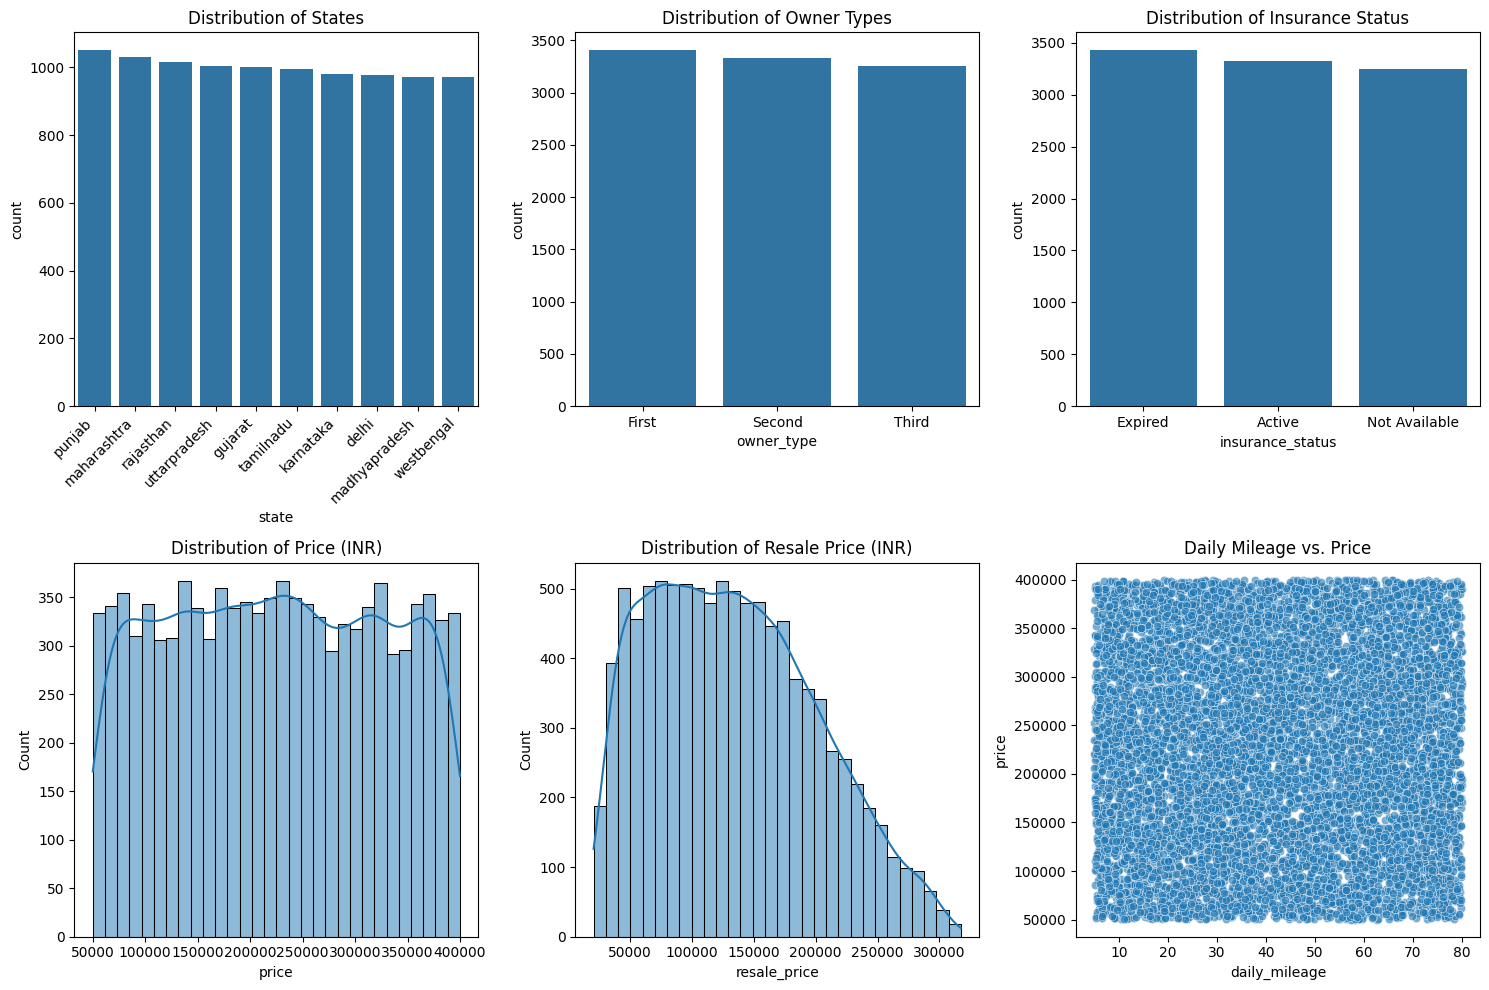

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Distribution of 'state'
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='state', order=df['state'].value_counts().index)
plt.title('Distribution of States')
plt.xticks(rotation=45, ha='right')

# Distribution of 'owner_type'
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='owner_type', order=df['owner_type'].value_counts().index)
plt.title('Distribution of Owner Types')

# Distribution of 'insurance_status'
plt.subplot(2, 3, 3)
sns.countplot(data=df, x='insurance_status', order=df['insurance_status'].value_counts().index)
plt.title('Distribution of Insurance Status')

# Distribution of 'price'
plt.subplot(2, 3, 4)
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Price (INR)')

# Distribution of 'resale_price'
plt.subplot(2, 3, 5)
sns.histplot(df['resale_price'], kde=True, bins=30)
plt.title('Distribution of Resale Price (INR)')

# Relationship between 'daily_mileage' and 'price'
plt.subplot(2, 3, 6)
sns.scatterplot(data=df, x='daily_mileage', y='price', alpha=0.6)
plt.title('Daily Mileage vs. Price')

plt.tight_layout()
plt.show()

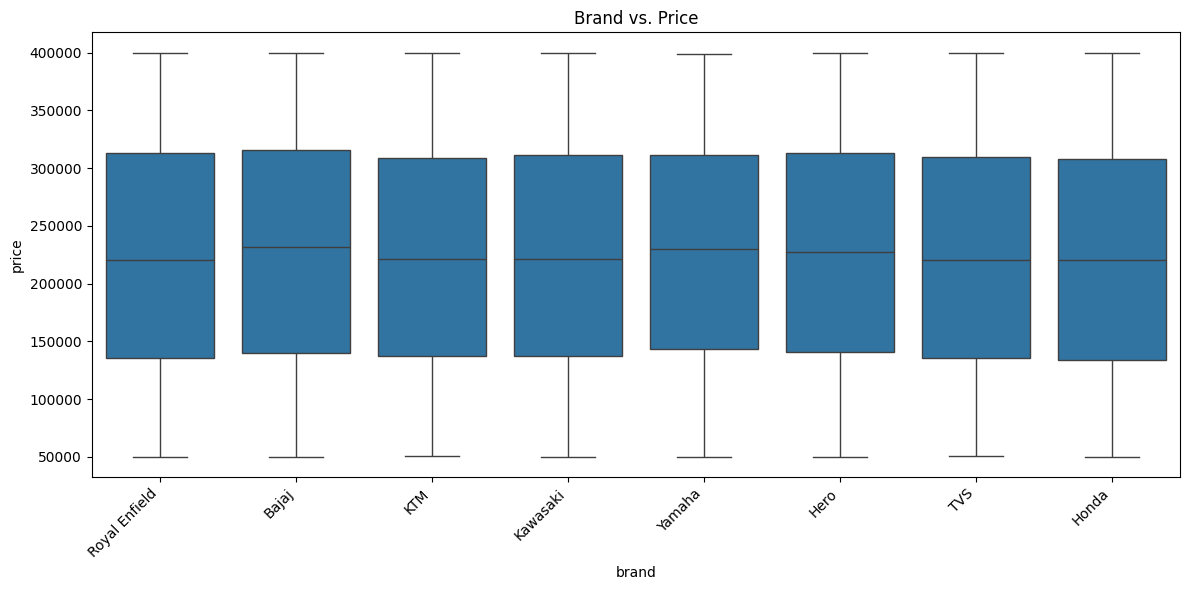

In [32]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='brand', y='price')
plt.title('Brand vs. Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

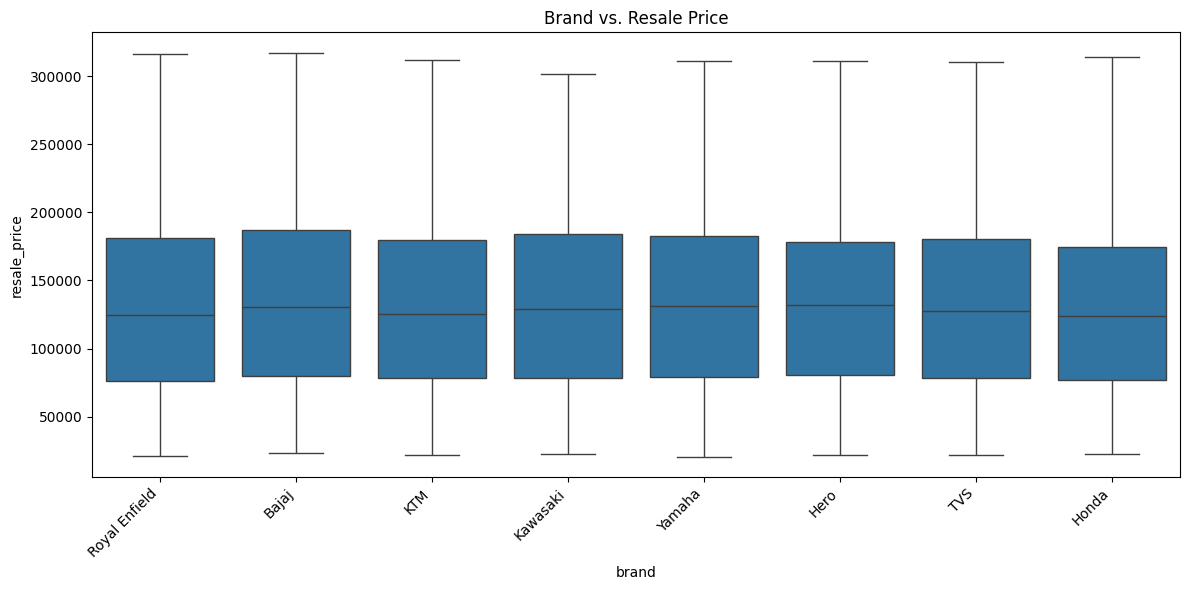

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='brand', y='resale_price')
plt.title('Brand vs. Resale Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

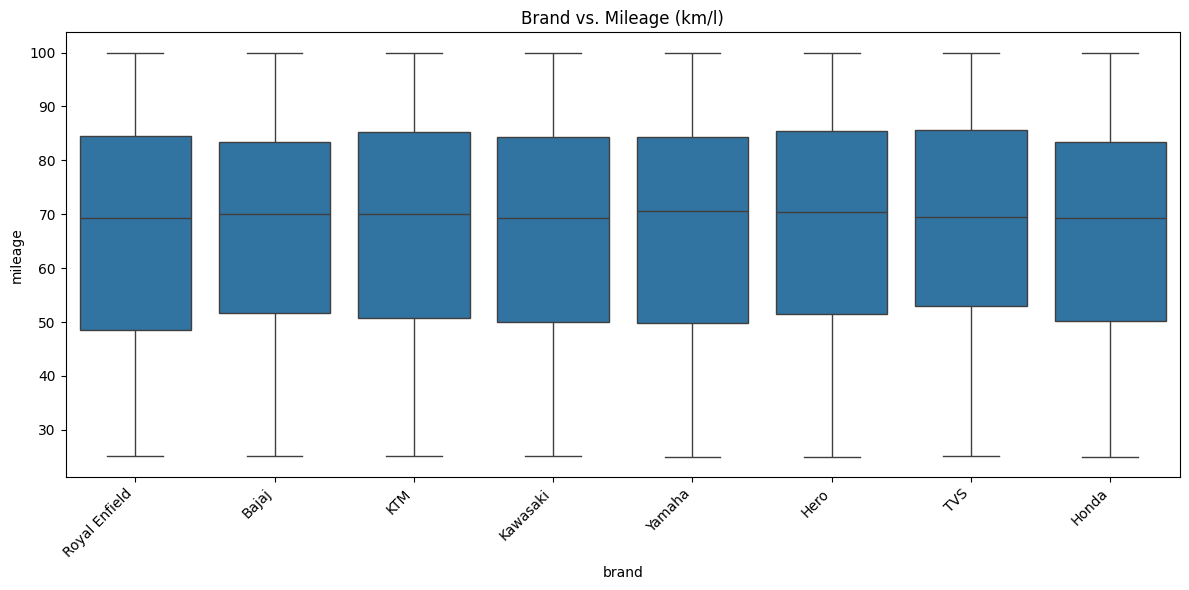

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='brand', y='mileage')
plt.title('Brand vs. Mileage (km/l)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

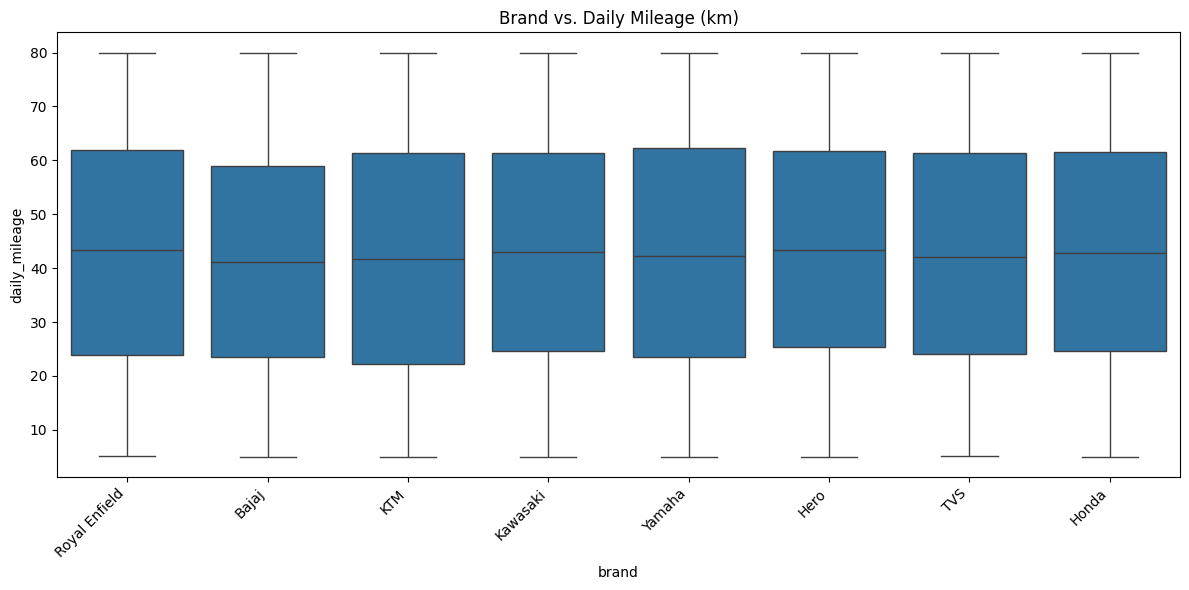

In [35]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='brand', y='daily_mileage')
plt.title('Brand vs. Daily Mileage (km)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

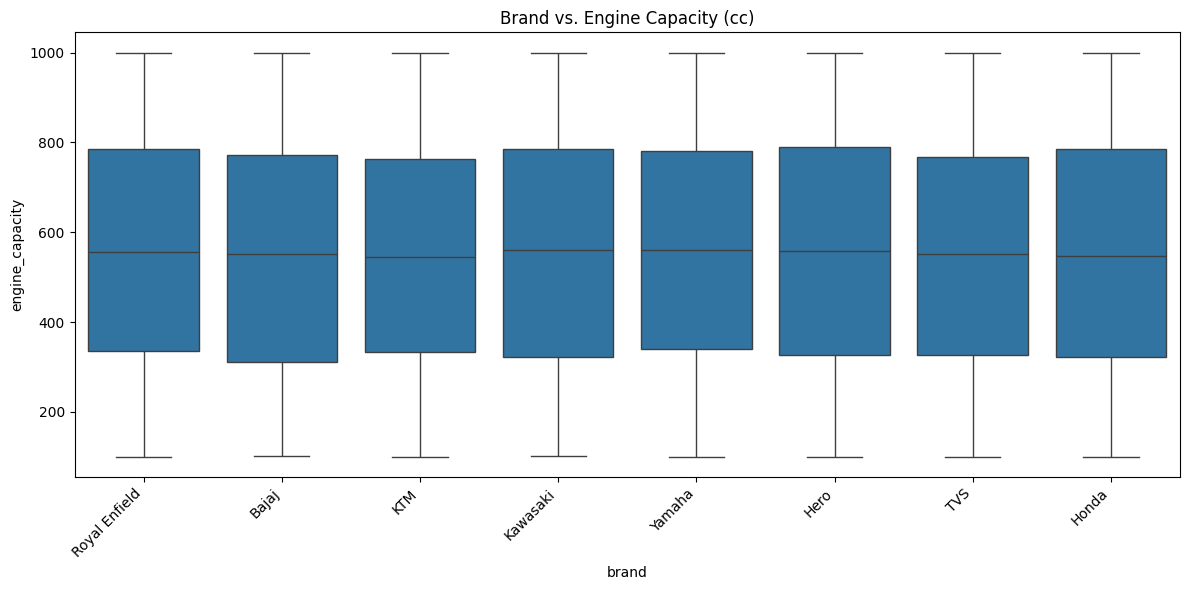

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='brand', y='engine_capacity')
plt.title('Brand vs. Engine Capacity (cc)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
clean_data = df.copy()
clean_data.to_csv('clean_bike_sales.csv')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2015'),
  Text(1, 0, '2016'),
  Text(2, 0, '2017'),
  Text(3, 0, '2018'),
  Text(4, 0, '2019'),
  Text(5, 0, '2020'),
  Text(6, 0, '2021'),
  Text(7, 0, '2022'),
  Text(8, 0, '2023'),
  Text(9, 0, '2024')])

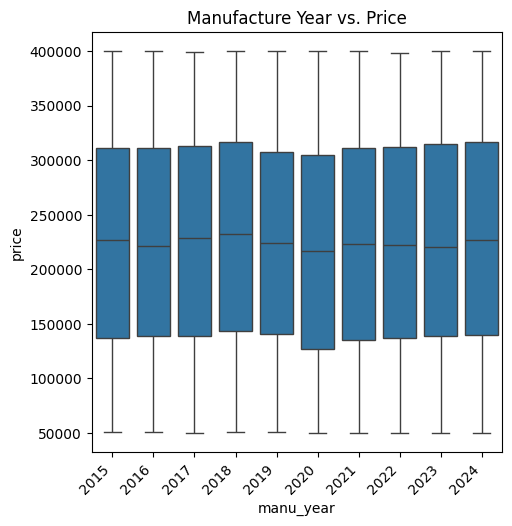

In [38]:
plt.figure(figsize=(18, 12))

# manu_year vs. price
plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='manu_year', y='price')
plt.title('Manufacture Year vs. Price')
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2015'),
  Text(1, 0, '2016'),
  Text(2, 0, '2017'),
  Text(3, 0, '2018'),
  Text(4, 0, '2019'),
  Text(5, 0, '2020'),
  Text(6, 0, '2021'),
  Text(7, 0, '2022'),
  Text(8, 0, '2023'),
  Text(9, 0, '2024')])

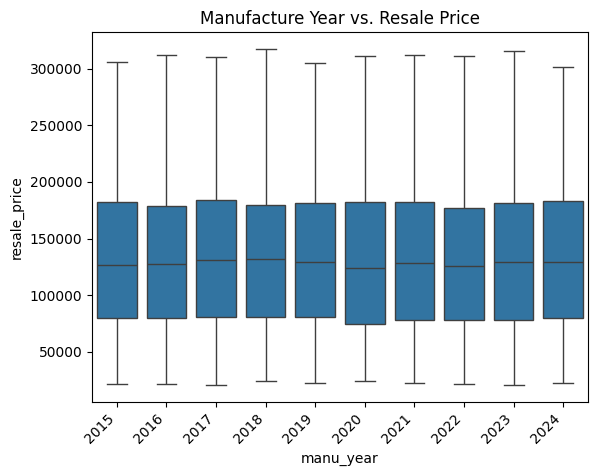

In [39]:
# manu_year vs. resale_price
sns.boxplot(data=df, x='manu_year', y='resale_price')
plt.title('Manufacture Year vs. Resale Price')
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2015'),
  Text(1, 0, '2016'),
  Text(2, 0, '2017'),
  Text(3, 0, '2018'),
  Text(4, 0, '2019'),
  Text(5, 0, '2020'),
  Text(6, 0, '2021'),
  Text(7, 0, '2022'),
  Text(8, 0, '2023'),
  Text(9, 0, '2024')])

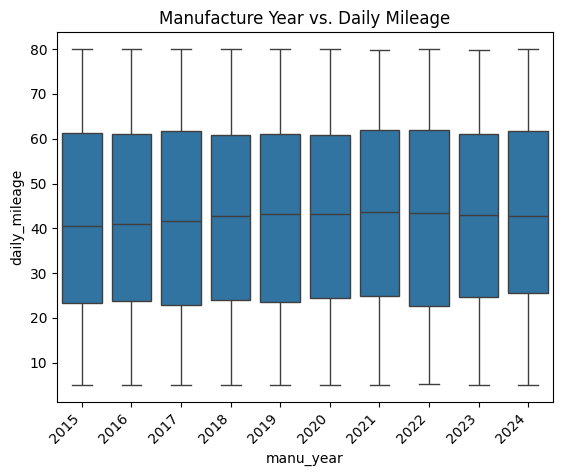

In [40]:
# manu_year vs. daily_mileage
sns.boxplot(data=df, x='manu_year', y='daily_mileage')
plt.title('Manufacture Year vs. Daily Mileage')
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2015'),
  Text(1, 0, '2016'),
  Text(2, 0, '2017'),
  Text(3, 0, '2018'),
  Text(4, 0, '2019'),
  Text(5, 0, '2020'),
  Text(6, 0, '2021'),
  Text(7, 0, '2022'),
  Text(8, 0, '2023'),
  Text(9, 0, '2024')])

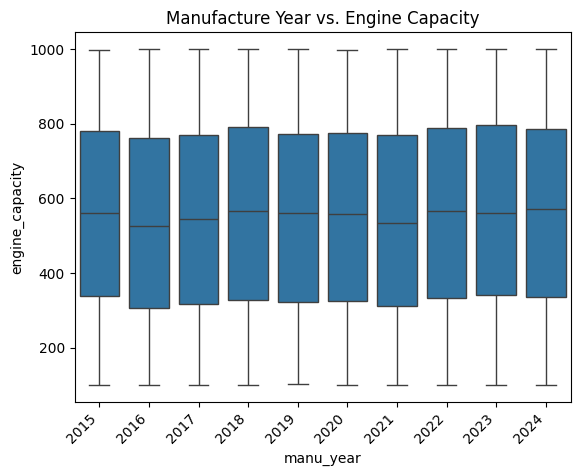

In [41]:
# manu_year vs. engine_capacity
sns.boxplot(data=df, x='manu_year', y='engine_capacity')
plt.title('Manufacture Year vs. Engine Capacity')
plt.xticks(rotation=45, ha='right')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2015'),
  Text(1, 0, '2016'),
  Text(2, 0, '2017'),
  Text(3, 0, '2018'),
  Text(4, 0, '2019'),
  Text(5, 0, '2020'),
  Text(6, 0, '2021'),
  Text(7, 0, '2022'),
  Text(8, 0, '2023'),
  Text(9, 0, '2024')])

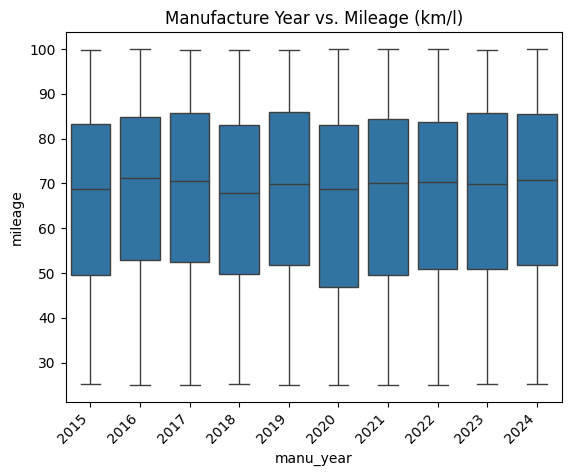

In [42]:
# manu_year vs. mileage
sns.boxplot(data=df, x='manu_year', y='mileage')
plt.title('Manufacture Year vs. Mileage (km/l)')
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2015'),
  Text(1, 0, '2016'),
  Text(2, 0, '2017'),
  Text(3, 0, '2018'),
  Text(4, 0, '2019'),
  Text(5, 0, '2020'),
  Text(6, 0, '2021'),
  Text(7, 0, '2022'),
  Text(8, 0, '2023'),
  Text(9, 0, '2024')])

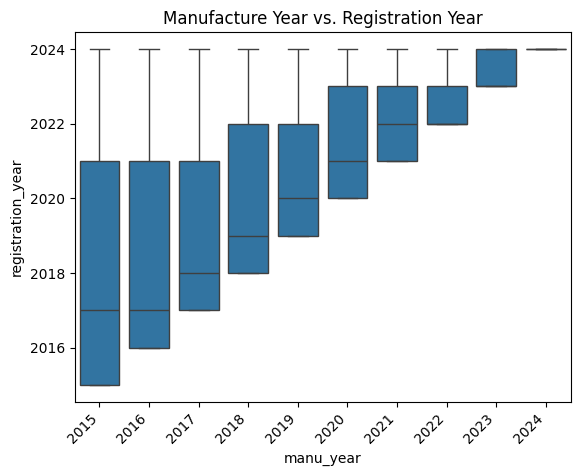

In [43]:
# manu_year vs. registration_year
sns.boxplot(data=df, x='manu_year', y='registration_year')
plt.title('Manufacture Year vs. Registration Year')
plt.xticks(rotation=45, ha='right')

In [44]:
# sns.pairplot(df)

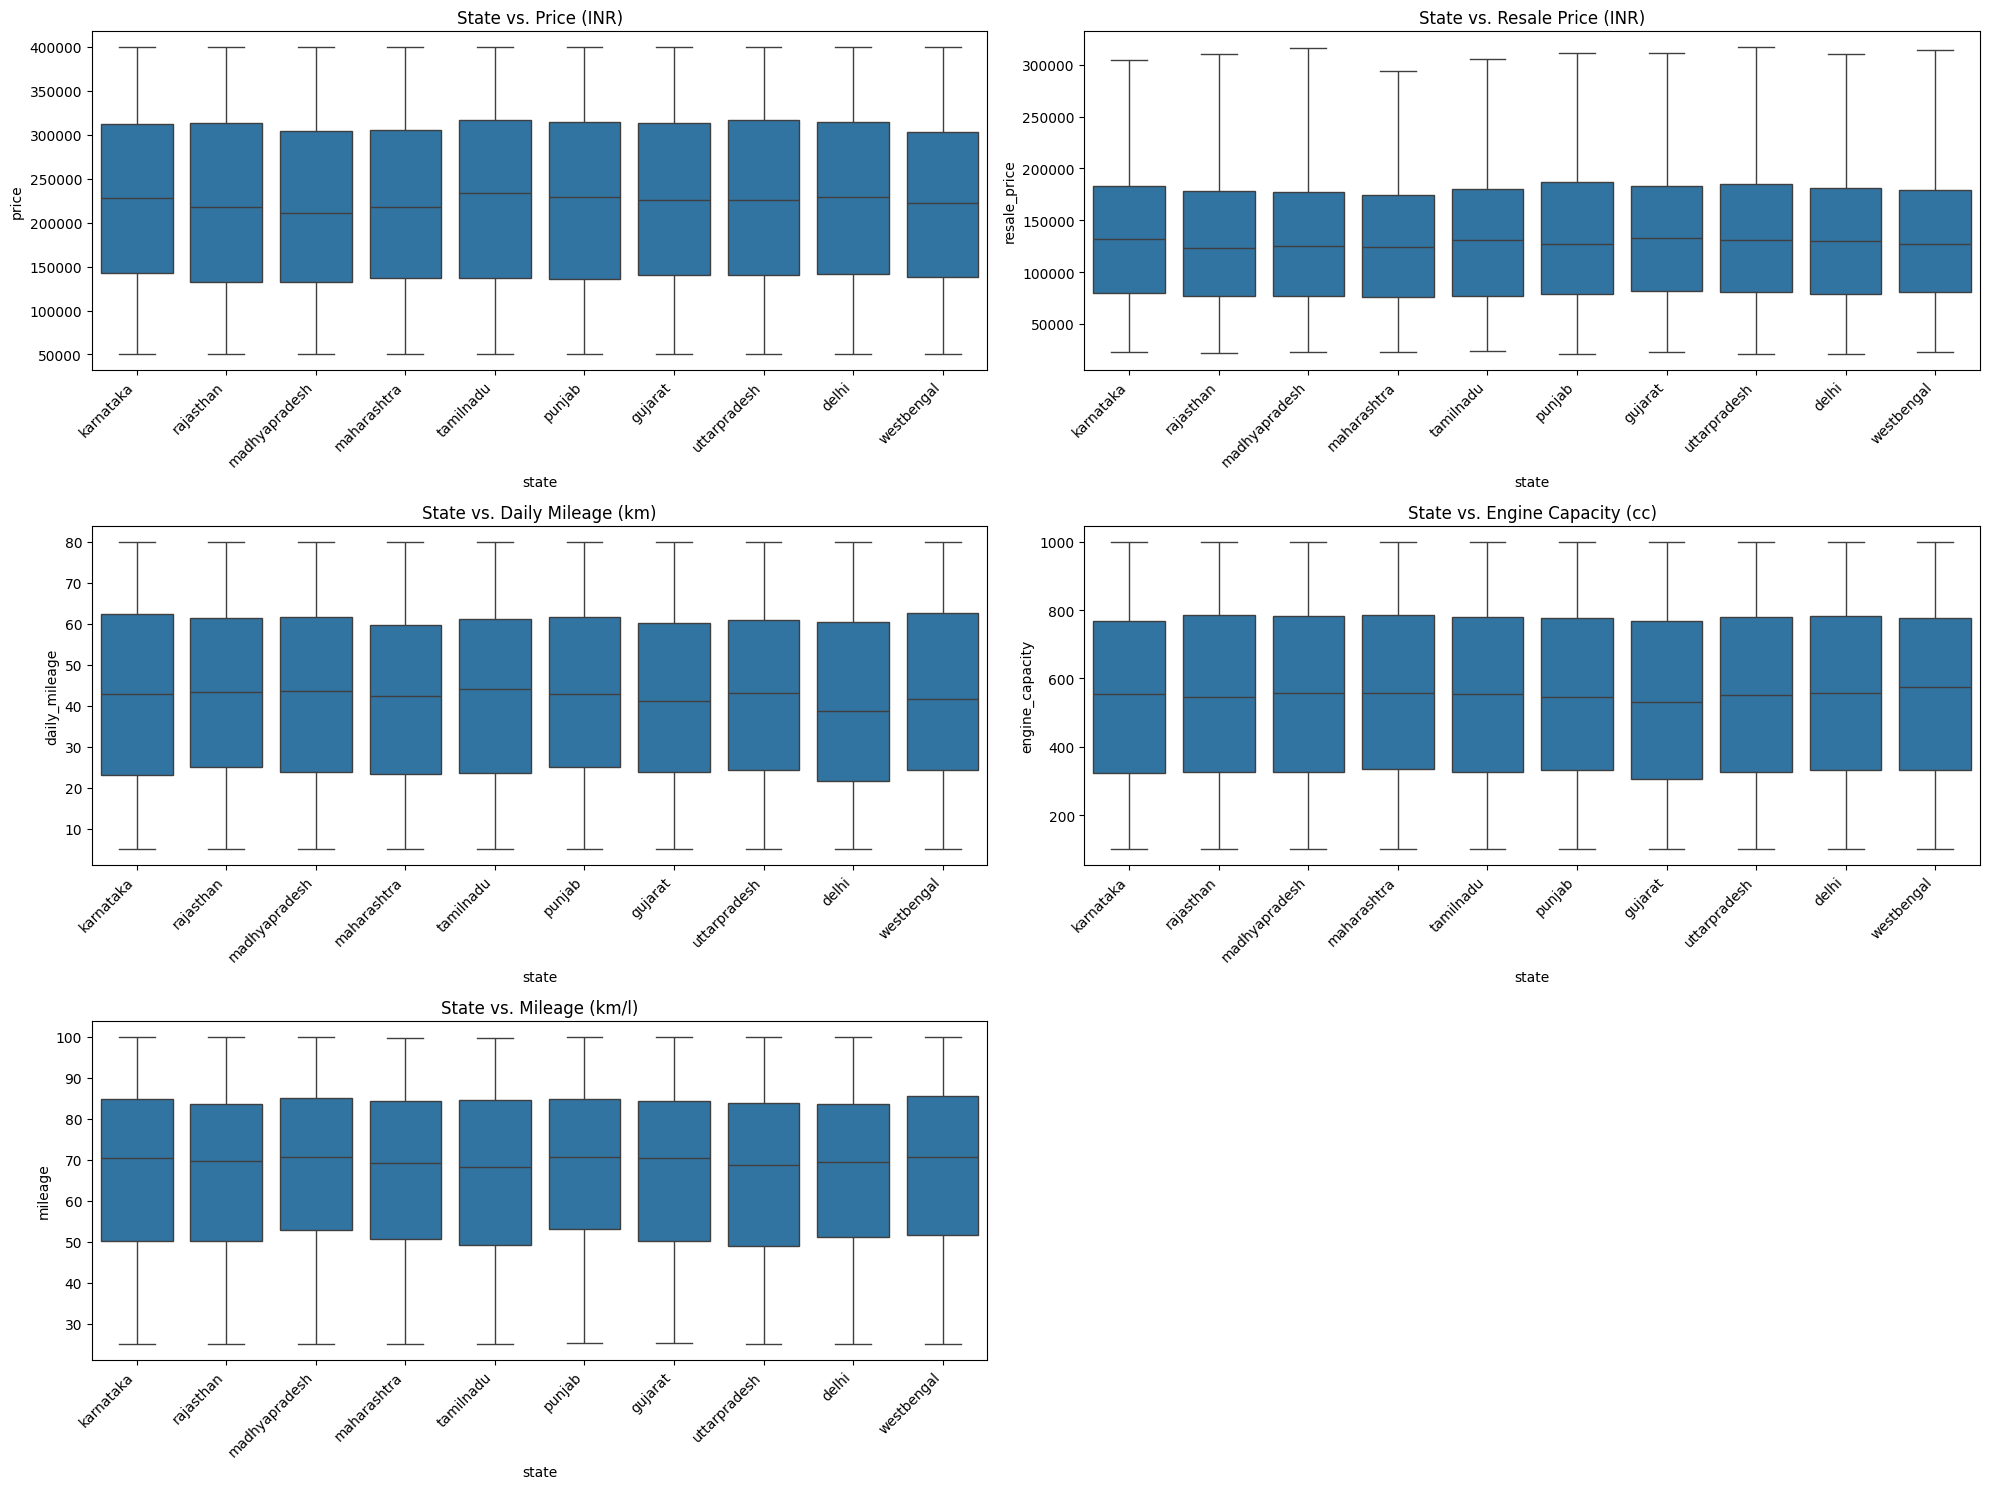

In [45]:
plt.figure(figsize=(20, 15))

# State vs. Price
plt.subplot(3, 2, 1)
sns.boxplot(data=df, x='state', y='price')
plt.title('State vs. Price (INR)')
plt.xticks(rotation=45, ha='right')

# State vs. Resale Price
plt.subplot(3, 2, 2)
sns.boxplot(data=df, x='state', y='resale_price')
plt.title('State vs. Resale Price (INR)')
plt.xticks(rotation=45, ha='right')

# State vs. Daily Mileage
plt.subplot(3, 2, 3)
sns.boxplot(data=df, x='state', y='daily_mileage')
plt.title('State vs. Daily Mileage (km)')
plt.xticks(rotation=45, ha='right')

# State vs. Engine Capacity
plt.subplot(3, 2, 4)
sns.boxplot(data=df, x='state', y='engine_capacity')
plt.title('State vs. Engine Capacity (cc)')
plt.xticks(rotation=45, ha='right')

# State vs. Mileage (km/l)
plt.subplot(3, 2, 5)
sns.boxplot(data=df, x='state', y='mileage')
plt.title('State vs. Mileage (km/l)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

model building


In [46]:
df.head()

,state,daily_mileage,brand,model,price,manu_year,engine_capacity,fuel_type,mileage,owner_type,registration_year,insurance_status,seller_type,resale_price,city_tier
0,karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,3
1,rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,3
2,madhyapradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,3
3,karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,1
4,madhyapradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,3


In [47]:
X = df[['state','brand','engine_capacity','fuel_type','mileage','owner_type','insurance_status','seller_type','resale_price','city_tier']]
print(X.shape)
y = df['price']
print(y.shape)

(10000, 10)
(10000,)


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , accuracy_score
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder , MinMaxScaler , StandardScaler, OrdinalEncoder , LabelEncoder

In [49]:
trans = make_column_transformer(
    (OrdinalEncoder(),['fuel_type','owner_type','insurance_status','seller_type','city_tier']),
    (OneHotEncoder(drop='first'),['state','brand']),
    remainder='passthrough'
)

In [50]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr = LinearRegression()

pipe1 = make_pipeline(
    trans,
    lr
)

pipe1.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['fuel_type', 'owner_type',
                                                   'insurance_status',
                                                   'seller_type',
                                                   'city_tier']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['state', 'brand'])])),
                ('linearregression', LinearRegression())])

In [51]:
y_pred = pipe1.predict(X_test)

print('mean sqared error is :',mean_squared_error(y_test,y_pred))
print('r2 score is :',r2_score(y_test,y_pred))

mean sqared error is : 1909744448.8618531
r2 score is : 0.8096553787644338


In [52]:
from sklearn.linear_model import Ridge , Lasso

pipe2 = make_pipeline(
    trans,
    Ridge()
)

pipe2.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['fuel_type', 'owner_type',
                                                   'insurance_status',
                                                   'seller_type',
                                                   'city_tier']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['state', 'brand'])])),
                ('ridge', Ridge())])

In [53]:
y_pred = pipe2.predict(X_test)

print('mean sqared error is :',mean_squared_error(y_test,y_pred))
print('r2 score is :',r2_score(y_test,y_pred))

mean sqared error is : 1909692540.3447506
r2 score is : 0.8096605524969888


In [54]:
from sklearn.linear_model import Ridge , Lasso

pipe3 = make_pipeline(
    trans,
    Lasso()
)

pipe3.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['fuel_type', 'owner_type',
                                                   'insurance_status',
                                                   'seller_type',
                                                   'city_tier']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['state', 'brand'])])),
                ('lasso', Lasso())])

In [55]:
y_pred = pipe3.predict(X_test)

print('mean sqared error is :',mean_squared_error(y_test,y_pred))
print('r2 score is :',r2_score(y_test,y_pred))

mean sqared error is : 1909641660.0842593
r2 score is : 0.8096656237429962


In [56]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Decision Tree Regressor
pipe4 = make_pipeline(
    trans,
    DecisionTreeRegressor(random_state=42)
)

pipe4.fit(X_train, y_train)
y_pred_dt = pipe4.predict(X_test)
print('--- Decision Tree Regressor ---')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_dt))
print('R2 Score:', r2_score(y_test, y_pred_dt))


--- Decision Tree Regressor ---
Mean Squared Error: 3016160565.086
R2 Score: 0.6993786573438676


In [67]:
# Random Forest Regressor
pipe5 = make_pipeline(
    trans,
    RandomForestRegressor(random_state=42, n_estimators=1000)
)

pipe5.fit(X_train, y_train)
y_pred_rf = pipe5.predict(X_test)
print('--- Random Forest Regressor ---')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_rf))
print('R2 Score:', r2_score(y_test, y_pred_rf))

--- Random Forest Regressor ---
Mean Squared Error: 1592398320.018491
R2 Score: 0.8412853325685998


In [58]:
# Gradient Boosting Regressor
pipe6 = make_pipeline(
    trans,
    GradientBoostingRegressor(random_state=42, n_estimators=1000, learning_rate=0.01)
)

pipe6.fit(X_train, y_train)
y_pred_gb = pipe6.predict(X_test)
print('--- Gradient Boosting Regressor ---')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_gb))
print('R2 Score:', r2_score(y_test, y_pred_gb))

--- Gradient Boosting Regressor ---
Mean Squared Error: 1513307288.8274236
R2 Score: 0.8491683518826061


In [59]:
from xgboost import XGBRegressor

# XGBoost Regressor
pipe7 = make_pipeline(
    trans,
    XGBRegressor(random_state=42, n_estimators=1000,eta=0.01 ,alpha=3)
)

pipe7.fit(X_train, y_train)
y_pred_xgb = pipe7.predict(X_test)
print('--- XGBoost Regressor ---')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_xgb))
print('R2 Score:', r2_score(y_test, y_pred_xgb))

--- XGBoost Regressor ---
Mean Squared Error: 1562538836.6468139
R2 Score: 0.8442614334055777


In [60]:
from sklearn.svm import SVR
pipe_svr = make_pipeline(
    trans,
    SVR(kernel='rbf', C=100, epsilon=0.1)
)

print('Training SVR model... This might take a while.')
pipe_svr.fit(X_train, y_train)

y_pred_svr = pipe_svr.predict(X_test)
print('\n--- Support Vector Regressor ---')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_svr))
print('R2 Score:', r2_score(y_test, y_pred_svr))

Training SVR model... This might take a while.

--- Support Vector Regressor ---
Mean Squared Error: 2240824389.034406
R2 Score: 0.7766565731659172


In [68]:
model_names = [
    'Linear Regression',
    'Ridge Regression',
    'Lasso Regression',
    'Decision Tree Regressor',
    'Random Forest Regressor',
    'Gradient Boosting Regressor',
    'XGBoost Regressor',
    'Support Vector Regressor'
]

if not hasattr(pipe2, 'is_fitted_') or not pipe2.is_fitted_:
    pipe2.fit(X_train, y_train)
if not hasattr(pipe3, 'is_fitted_') or not pipe3.is_fitted_:
    pipe3.fit(X_train, y_train)

r2_scores = [
    r2_score(y_test, pipe1.predict(X_test)),
    r2_score(y_test, pipe2.predict(X_test)),
    r2_score(y_test, pipe3.predict(X_test)),
    r2_score(y_test, pipe4.predict(X_test)),
    r2_score(y_test, pipe5.predict(X_test)),
    r2_score(y_test, pipe6.predict(X_test)),
    r2_score(y_test, pipe7.predict(X_test)),
    r2_score(y_test, pipe_svr.predict(X_test))
]

comparison_df = pd.DataFrame({
    'Model': model_names,
    'R2 Score': r2_scores
})

display(comparison_df.sort_values(by='R2 Score', ascending=False))

,Model,R2 Score
5,Gradient Boosting Regressor,0.849168
6,XGBoost Regressor,0.844261
4,Random Forest Regressor,0.841285
2,Lasso Regression,0.809666
1,Ridge Regression,0.809661
0,Linear Regression,0.809655
7,Support Vector Regressor,0.776657
3,Decision Tree Regressor,0.699379


In [64]:
trans = make_column_transformer(
    (OrdinalEncoder(),['fuel_type','owner_type','insurance_status','seller_type','city_tier']),
    (OneHotEncoder(handle_unknown='ignore', drop='first'),['state','brand']),
    remainder='passthrough'
)

final_pipe = make_pipeline(
    trans,
    XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    reg_alpha=1,
    colsample_bytree=0.9,
    subsample=0.7,
    max_depth=3)
)
final_pipe.fit(X_train,y_train)
y_pred = final_pipe.predict(X_test)
print('--- Tuned XGBoost Regressor ---')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))


--- Tuned XGBoost Regressor ---
Mean Squared Error: 1510437236.8082955
R2 Score: 0.8494544105564945


In [65]:
import pickle

pickle.dump(final_pipe,open('bike_price_prediction.pkl','wb'))

In [66]:
import sklearn
sklearn.__version__

'1.4.2'